# 03 - Model Training

Builds and trains the two models defined in `src/models/build_model.py`: a
baseline CNN trained from scratch, and an EfficientNetB0 transfer-learning
model trained in two stages (frozen backbone, then fine-tuning). Both are
trained on this project's custom stratified 80/10/10 training split (see
`01_data_exploration.ipynb`), ~6,551 images across 102 imbalanced classes —
still not much per class, which is the regime this project uses to produce
an honest baseline-vs-transfer-learning comparison.

Full test-set evaluation (confusion matrix, per-class F1, error analysis) is
deferred to `04_evaluation.ipynb` — this notebook only tracks training/validation
curves to select the best checkpoint of each model.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # silence TF/CUDA info-level logs

import sys
from pathlib import Path

from tensorflow import keras

sys.path.insert(0, str(Path.cwd().parent))

from src.config import BASELINE_MODEL_NAME, TRANSFER_MODEL_NAME
from src.data.dataset import load_datasets
from src.models.build_model import build_baseline_cnn, build_transfer_model, unfreeze_top_layers
from src.models.train import build_callbacks, fit_and_time, set_global_seed
from src.utils.visualization import plot_model_comparison, plot_training_curves, savefig

set_global_seed()

## Load datasets

Uses this project's custom stratified train/validation/test split, loaded and pipelined exactly as
in `01_data_exploration.ipynb` / `02_preprocessing_augmentation.ipynb` — 224x224
`float32` batches, augmentation applied inside the model graph rather than here.

In [2]:
train_ds, val_ds, test_ds, class_names, info = load_datasets()
print(f"Classes: {len(class_names)}")

Classes: 102


## Baseline CNN (trained from scratch)

Trained purely to quantify, in this project's own numbers, how much transfer
learning helps on a ~6,551-image, 102-class, imbalanced problem — it is not expected to
generalize well on its own.

In [3]:
baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

Model: "baseline_cnn"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         


 augmentation (Sequential)   (None, 224, 224, 3)       0         


...

 dense_1 (Dense)             (None, 102)               26214     


Total params: 482342 (1.84 MB)


Trainable params: 481382 (1.84 MB)


Non-trainable params: 960 (3.75 KB)


_________________________________________________________________


In [4]:
baseline_callbacks = build_callbacks(BASELINE_MODEL_NAME, patience=6)
baseline_history, baseline_time = fit_and_time(
    baseline_model,
    train_ds,
    val_ds,
    epochs=20,
    callbacks=baseline_callbacks,
    model_name=BASELINE_MODEL_NAME,
)
print(f"Baseline training time: {baseline_time:.1f}s over {len(baseline_history.history['loss'])} epochs")

Epoch 1/20


      1/Unknown - 5s 5s/step - loss: 4.7984 - accuracy: 0.0000e+00

      2/Unknown - 7s 2s/step - loss: 4.8403 - accuracy: 0.0156    

      3/Unknown - 9s 2s/step - loss: 4.8229 - accuracy: 0.0104

      4/Unknown - 10s 2s/step - loss: 4.8572 - accuracy: 0.0078

...

203/205 [============================>.] - ETA: 2s - loss: 1.3480 - accuracy: 0.6261

204/205 [============================>.] - ETA: 1s - loss: 1.3456 - accuracy: 0.6267

205/205 [==============================] - ETA: 0s - loss: 1.3454 - accuracy: 0.6262

205/205 [==============================] - 280s 1s/step - loss: 1.3454 - accuracy: 0.6262 - val_loss: 1.8153 - val_accuracy: 0.5360 - lr: 2.5000e-04


Baseline training time: 5938.8s over 20 epochs


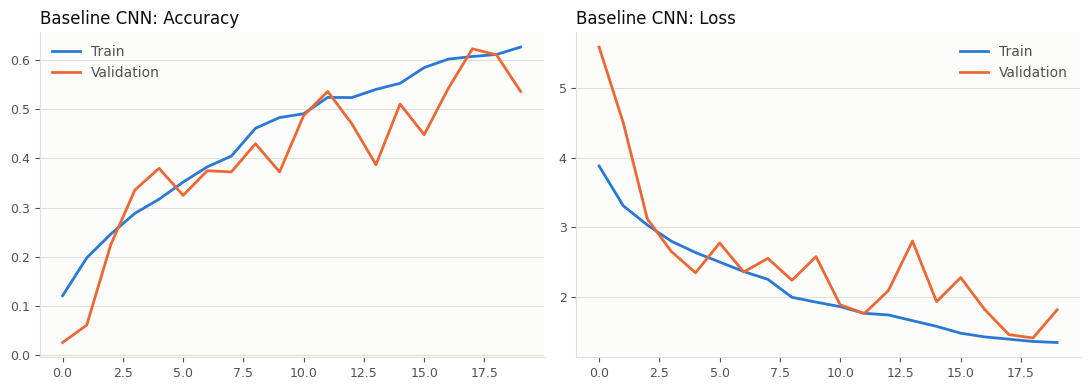

In [5]:
fig = plot_training_curves(baseline_history.history, title_prefix="Baseline CNN")
savefig(fig, "03_baseline_training_curves.png")

## Transfer learning — Stage 1: frozen backbone

`EfficientNetB0` (ImageNet weights) is frozen; only the new
`GlobalAveragePooling2D -> Dropout -> Dense(102, softmax)` head is trained, so
the pretrained features are not disturbed while the head adapts to this
output space.

In [6]:
transfer_model, base_model = build_transfer_model()
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
transfer_model.summary()

Model: "efficientnetb0_transfer"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         


 augmentation (Sequential)   (None, 224, 224, 3)       0         


...

 dense_2 (Dense)             (None, 102)               130662    


Total params: 4180233 (15.95 MB)


Trainable params: 130662 (510.40 KB)


Non-trainable params: 4049571 (15.45 MB)


_________________________________________________________________


In [7]:
transfer_callbacks = build_callbacks(TRANSFER_MODEL_NAME, patience=6)
transfer_history, transfer_time = fit_and_time(
    transfer_model,
    train_ds,
    val_ds,
    epochs=10,
    callbacks=transfer_callbacks,
    model_name=TRANSFER_MODEL_NAME,
)
print(f"Frozen-backbone training time: {transfer_time:.1f}s over {len(transfer_history.history['loss'])} epochs")

Epoch 1/10


      1/Unknown - 6s 6s/step - loss: 4.8433 - accuracy: 0.0000e+00

      2/Unknown - 7s 600ms/step - loss: 4.8487 - accuracy: 0.0000e+00

      3/Unknown - 8s 605ms/step - loss: 4.8458 - accuracy: 0.0000e+00

      4/Unknown - 8s 610ms/step - loss: 4.8714 - accuracy: 0.0000e+00

...

203/205 [============================>.] - ETA: 1s - loss: 0.1966 - accuracy: 0.9675

204/205 [============================>.] - ETA: 0s - loss: 0.1967 - accuracy: 0.9674

205/205 [==============================] - ETA: 0s - loss: 0.1965 - accuracy: 0.9675

205/205 [==============================] - 145s 698ms/step - loss: 0.1965 - accuracy: 0.9675 - val_loss: 0.2466 - val_accuracy: 0.9414 - lr: 0.0010


Frozen-backbone training time: 1482.6s over 10 epochs


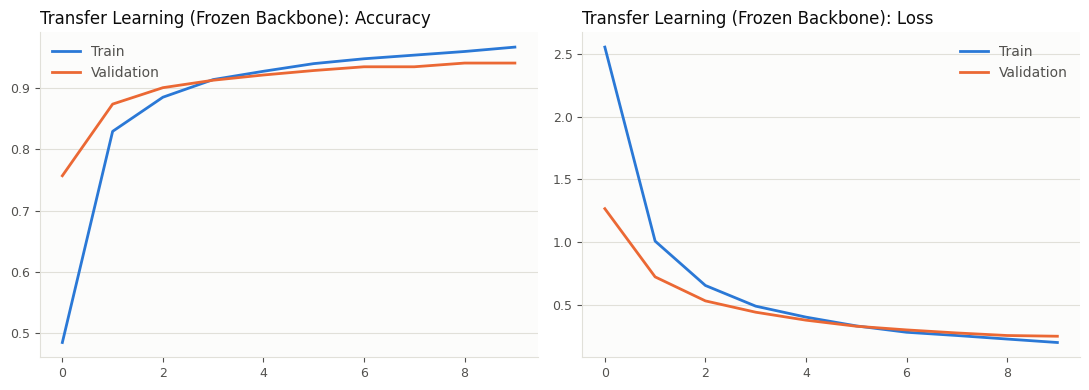

In [8]:
fig = plot_training_curves(transfer_history.history, title_prefix="Transfer Learning (Frozen Backbone)")
savefig(fig, "03_transfer_frozen_training_curves.png")

## Transfer learning — Stage 2: fine-tuning

The top 20 layers of the backbone are unfrozen and trained at a much lower
learning rate (`1e-5` vs. `1e-3`), nudging the pretrained features toward this
dataset rather than overwriting them. `BatchNormalization` layers stay frozen
even within that unfrozen block (see `unfreeze_top_layers` docstring) since
updating BN statistics is a small-sample-size risk for the rarest classes
(as few as ~32 training images each).

In [9]:
unfreeze_top_layers(base_model, num_layers=20)
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print(f"Trainable backbone layers: {trainable_layers}/{len(base_model.layers)}")

Trainable backbone layers: 15/238


In [10]:
FINETUNED_MODEL_NAME = f"{TRANSFER_MODEL_NAME}_finetuned"

finetune_callbacks = build_callbacks(FINETUNED_MODEL_NAME, patience=6)
finetune_history, finetune_time = fit_and_time(
    transfer_model,
    train_ds,
    val_ds,
    epochs=8,
    callbacks=finetune_callbacks,
    model_name=FINETUNED_MODEL_NAME,
)
print(f"Fine-tuning time: {finetune_time:.1f}s over {len(finetune_history.history['loss'])} epochs")

Epoch 1/8


      1/Unknown - 9s 9s/step - loss: 0.1466 - accuracy: 1.0000

      2/Unknown - 10s 669ms/step - loss: 0.2190 - accuracy: 0.9531

      3/Unknown - 11s 679ms/step - loss: 0.2415 - accuracy: 0.9375

      4/Unknown - 11s 680ms/step - loss: 0.2013 - accuracy: 0.9453

...

203/205 [============================>.] - ETA: 1s - loss: 0.0770 - accuracy: 0.9803

204/205 [============================>.] - ETA: 0s - loss: 0.0768 - accuracy: 0.9804

205/205 [==============================] - ETA: 0s - loss: 0.0765 - accuracy: 0.9805

205/205 [==============================] - 163s 780ms/step - loss: 0.0765 - accuracy: 0.9805 - val_loss: 0.1531 - val_accuracy: 0.9548 - lr: 1.0000e-05


Fine-tuning time: 1280.7s over 8 epochs


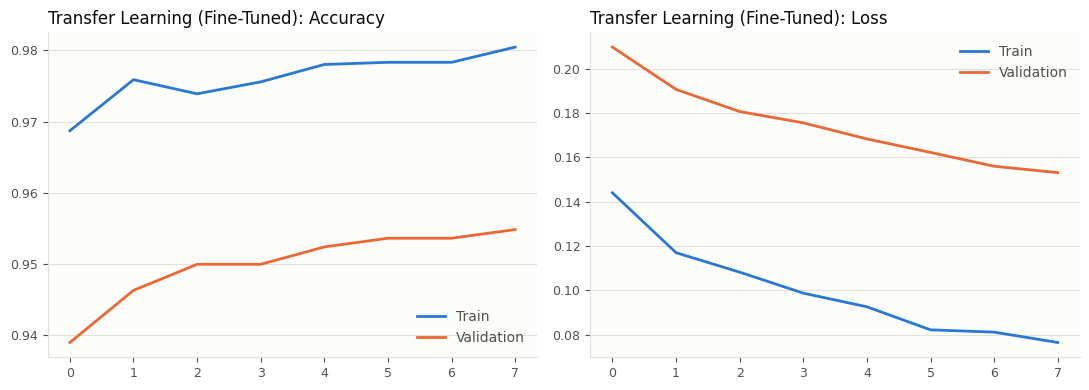

In [11]:
fig = plot_training_curves(finetune_history.history, title_prefix="Transfer Learning (Fine-Tuned)")
savefig(fig, "03_transfer_finetuned_training_curves.png")

## Training summary — baseline vs. transfer learning

Compares the **best validation accuracy** reached at each stage (the epoch
each `ModelCheckpoint` actually saved). This is a training-time sanity check,
not the final evaluation — `04_evaluation.ipynb` reports test-set accuracy and
macro precision/recall/F1 on the held-out 819-image test split.

          Baseline CNN: 62.3% best validation accuracy
     Transfer (frozen): 94.1% best validation accuracy
 Transfer (fine-tuned): 95.5% best validation accuracy


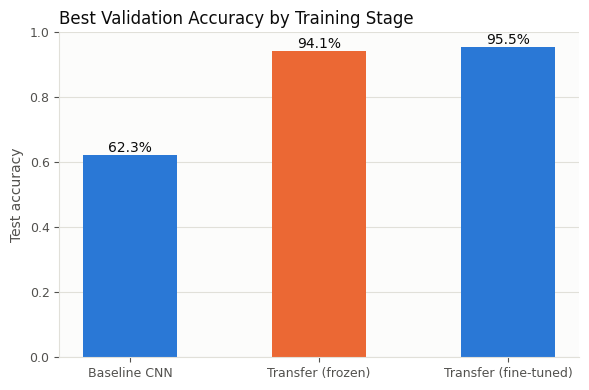

In [12]:
best_baseline_val_acc = max(baseline_history.history["val_accuracy"])
best_frozen_val_acc = max(transfer_history.history["val_accuracy"])
best_finetuned_val_acc = max(finetune_history.history["val_accuracy"])

names = ["Baseline CNN", "Transfer (frozen)", "Transfer (fine-tuned)"]
accuracies = [best_baseline_val_acc, best_frozen_val_acc, best_finetuned_val_acc]
for name, acc in zip(names, accuracies):
    print(f"{name:>22}: {acc:.1%} best validation accuracy")

fig = plot_model_comparison(names, accuracies, title="Best Validation Accuracy by Training Stage")
savefig(fig, "03_model_comparison_val_accuracy.png")

## Key takeaways

- The baseline CNN, trained from scratch on approximately 32-206 training
  images per class, learns useful patterns but performs substantially worse
  than the pretrained model — it exists to make the transfer-learning gain
  measurable rather than assumed.
- The frozen-backbone stage should already outperform the baseline by a wide
  margin, since ImageNet-pretrained features transfer well to fine-grained
  natural-image classification even with a linear head.
- Fine-tuning the top backbone layers at a low learning rate is expected to
  give a further, smaller improvement over the frozen-backbone stage, at the
  cost of a slower training step.
- All three checkpoints (`baseline_cnn.keras`, `efficientnetb0_transfer.keras`,
  `efficientnetb0_transfer_finetuned.keras`) and their training histories are
  saved under `models/checkpoints/` and `reports/`, ready for
  `04_evaluation.ipynb`.